STEP 0: Set Up

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")

STEP 1: Load Datasets

In [26]:
fact = pd.read_csv("fact_health_programs_cleaned.csv")
dim_program = pd.read_csv("dim_program_cleaned.csv")
dim_state = pd.read_csv("dim_state_cleaned.csv")
dim_dates = pd.read_csv("dim_dates_cleaned.csv")

# Merge fact with dimensions
df = fact.merge(dim_program, on="program_id", how="left") \
         .merge(dim_state, on="state_id", how="left") \
         .merge(dim_dates, on="date_id", how="left")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (6912, 29)


,fact_id,date_id,state_id,program_id,program_coverage_pct,people_screened,beneficiaries_reached,maternal_health_beneficiaries,child_immunization_count,children_population,...,latitude,longitude,population,area_sq_km,full_date,year,month_num,month_name,quarter,year_month
0,1,1,1,1,85.0,135857,115673,18060,8431493,13215224,...,15.9129,79.74,53900000,162970,2022-01-01,2022,1,January,Q1,2022-01
1,2,1,1,2,65.6,146606,102320,33298,11757218,13215224,...,15.9129,79.74,53900000,162970,2022-01-01,2022,1,January,Q1,2022-01
2,3,1,1,3,44.1,113323,97228,21849,11858458,13215224,...,15.9129,79.74,53900000,162970,2022-01-01,2022,1,January,Q1,2022-01
3,4,1,1,4,59.1,128387,86287,18308,8340853,13215224,...,15.9129,79.74,53900000,162970,2022-01-01,2022,1,January,Q1,2022-01
4,5,1,1,5,67.4,43864,20970,5091,9117993,13215224,...,15.9129,79.74,53900000,162970,2022-01-01,2022,1,January,Q1,2022-01


STEP 2: Data Quality Checks

In [27]:
print("Missing values:\n", df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())
print("\nData types:\n", df.dtypes)

Missing values:
 fact_id                          0
date_id                          0
state_id                         0
program_id                       0
program_coverage_pct             0
people_screened                  0
beneficiaries_reached            0
maternal_health_beneficiaries    0
child_immunization_count         0
children_population              0
adults_population                0
elderly_population               0
high_risk_individuals            0
chronic_disease_patients         0
health_vulnerability_index       0
socioeconomic_score              0
program_name                     0
state_name                       0
region                           0
latitude                         0
longitude                        0
population                       0
area_sq_km                       0
full_date                        0
year                             0
month_num                        0
month_name                       0
quarter                          0
yea

STEP 3: Descriptive Statistics

In [13]:
print(df.describe(include='all'))

            fact_id      date_id     state_id   program_id  \
count   6912.000000  6912.000000  6912.000000  6912.000000   
unique          NaN          NaN          NaN          NaN   
top             NaN          NaN          NaN          NaN   
freq            NaN          NaN          NaN          NaN   
mean    3456.500000    18.500000    16.500000     3.500000   
std     1995.466863    10.389046     9.233761     1.707949   
min        1.000000     1.000000     1.000000     1.000000   
25%     1728.750000     9.750000     8.750000     2.000000   
50%     3456.500000    18.500000    16.500000     3.500000   
75%     5184.250000    27.250000    24.250000     5.000000   
max     6912.000000    36.000000    32.000000     6.000000   

        program_coverage_pct  people_screened  beneficiaries_reached  \
count            6912.000000      6912.000000            6912.000000   
unique                   NaN              NaN                    NaN   
top                      NaN           

STEP 4: Univariate Analysis

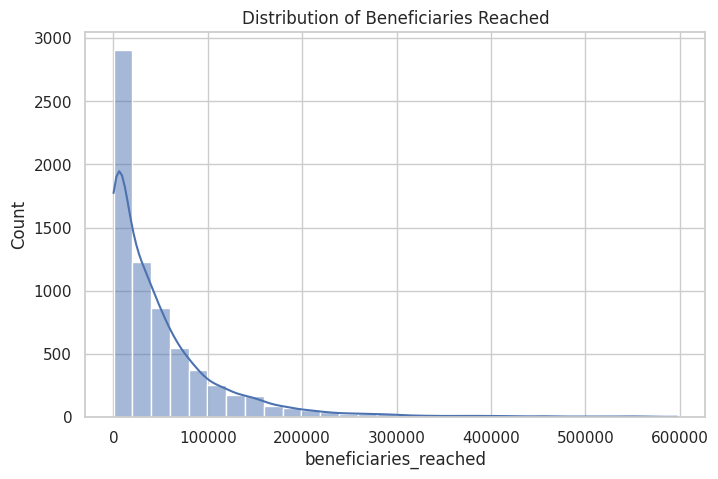

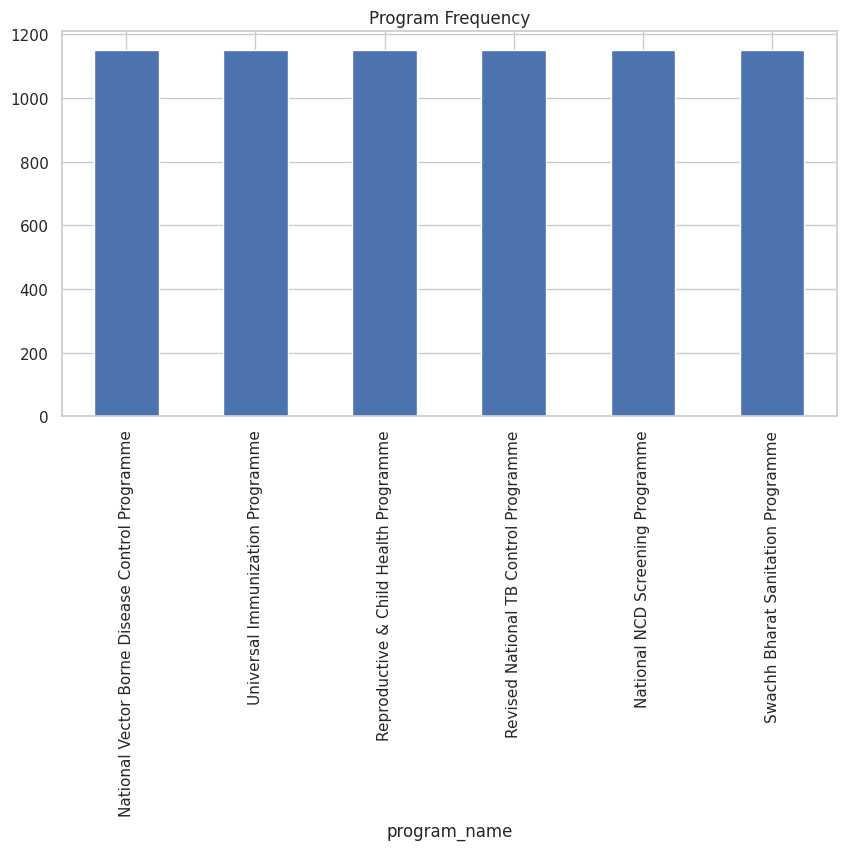

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(df['beneficiaries_reached'], bins=30, kde=True)
plt.title("Distribution of Beneficiaries Reached")
plt.show()

plt.figure(figsize=(10,5))
df['program_name'].value_counts().plot(kind='bar')
plt.title("Program Frequency")
plt.show()

STEP 5: Bivariate Analysis

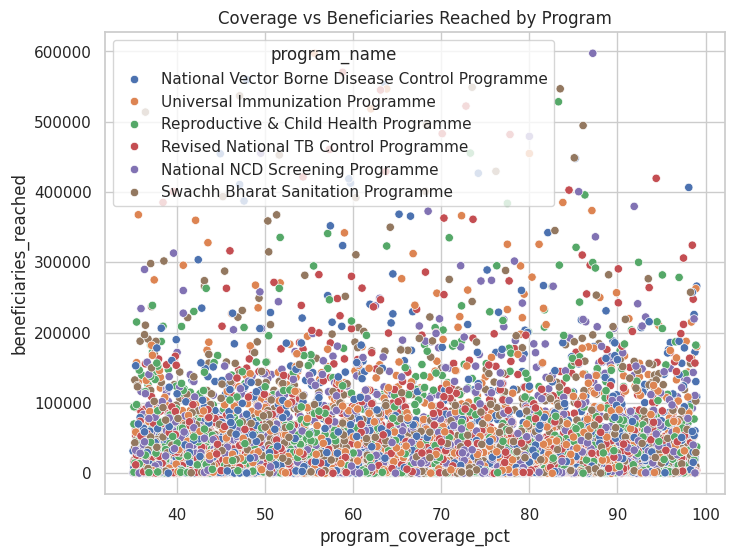

program_name
National NCD Screening Programme                   48765.942708
National Vector Borne Disease Control Programme    49997.314236
Reproductive & Child Health Programme              47819.098090
Revised National TB Control Programme              50638.813368
Swachh Bharat Sanitation Programme                 51202.700521
Universal Immunization Programme                   48199.701389
Name: beneficiaries_reached, dtype: float64


In [15]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='program_coverage_pct', y='beneficiaries_reached', data=df, hue='program_name')
plt.title("Coverage vs Beneficiaries Reached by Program")
plt.show()

print(df.groupby('program_name')['beneficiaries_reached'].mean())

STEP 6: Correlation Analysis

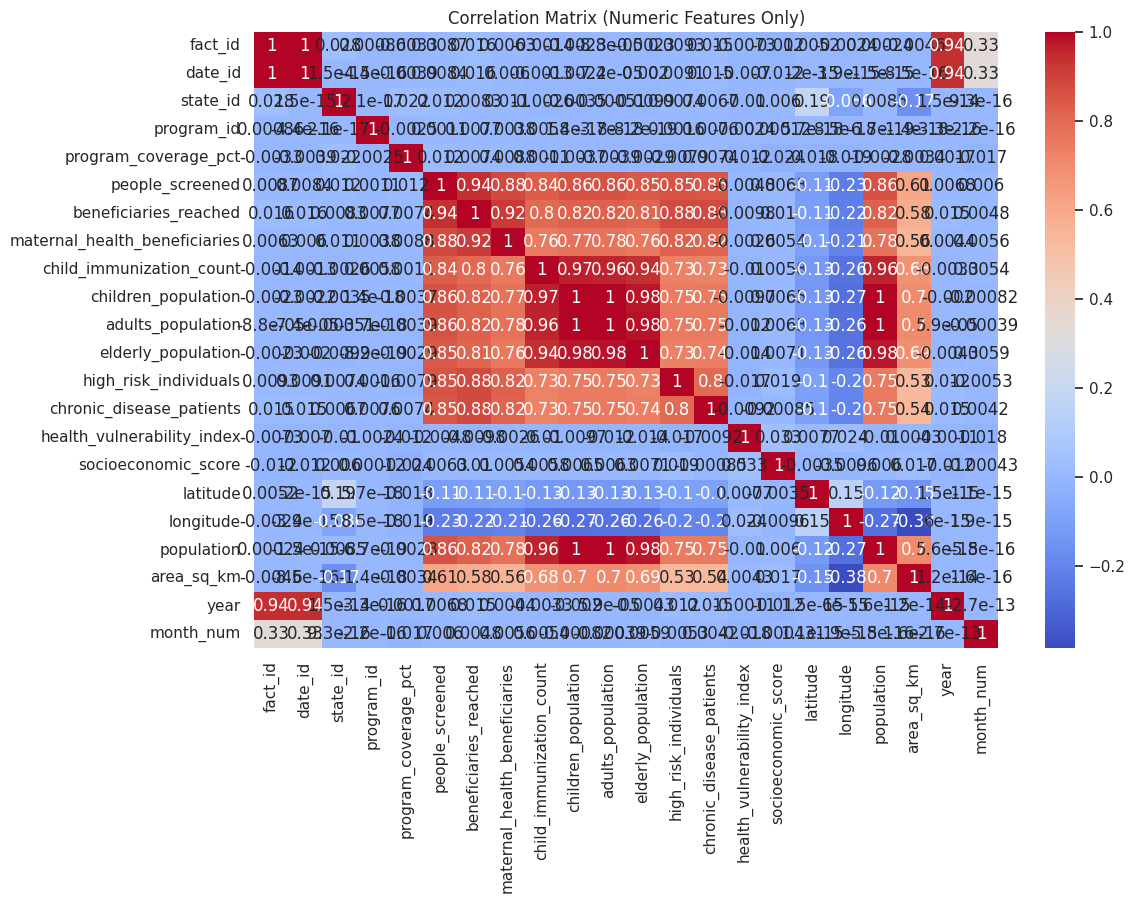

In [16]:
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix (Numeric Features Only)")
plt.show()

STEP 7: Outlier Detection

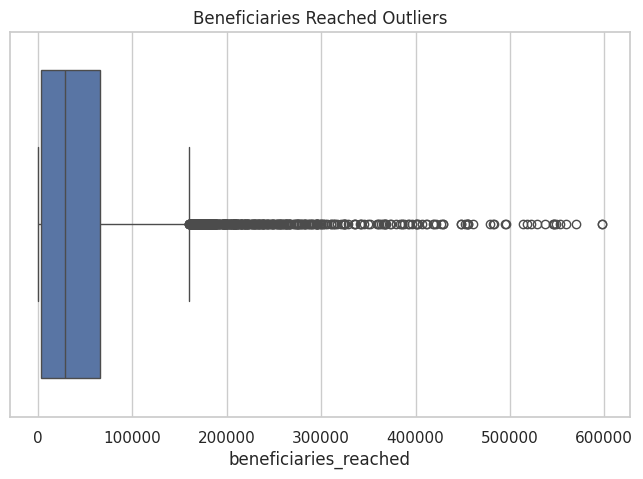

Outliers in beneficiaries_reached:
       fact_id  date_id  state_id  program_id  program_coverage_pct  \
81         82        1        14           4                  86.5   
152       153        1        26           3                  85.3   
154       155        1        26           5                  49.5   
155       156        1        26           6                  86.1   
211       212        2         4           2                  89.9   
...       ...      ...       ...         ...                   ...   
6683     6684       35        26           6                  98.3   
6871     6872       36        26           2                  83.8   
6872     6873       36        26           3                  77.5   
6873     6874       36        26           4                  56.1   
6875     6876       36        26           6                  76.2   

      people_screened  beneficiaries_reached  maternal_health_beneficiaries  \
81             329584                 255069

In [17]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['beneficiaries_reached'])
plt.title("Beneficiaries Reached Outliers")
plt.show()

z = np.abs(stats.zscore(df['beneficiaries_reached']))
outliers = df[z > 3]
print("Outliers in beneficiaries_reached:\n", outliers)

STEP 8: Time Series Trends

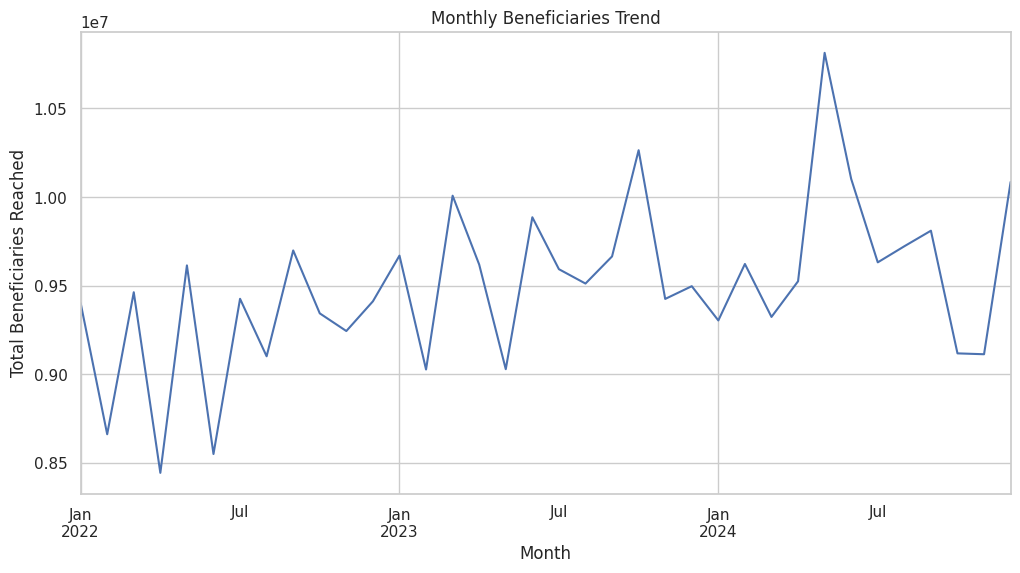

In [18]:
df['full_date'] = pd.to_datetime(df['full_date'])
monthly = df.groupby(df['full_date'].dt.to_period("M"))['beneficiaries_reached'].sum()

monthly.plot(figsize=(12,6))
plt.title("Monthly Beneficiaries Trend")
plt.xlabel("Month")
plt.ylabel("Total Beneficiaries Reached")
plt.show()

In [ ]:
STEP 9: Region-wise Comparision

Beneficiaries Reached by Region:
 region
North        110188559
East          74588736
South         67757621
West          47571211
Central       27937389
Northeast     13666837
Name: beneficiaries_reached, dtype: int64


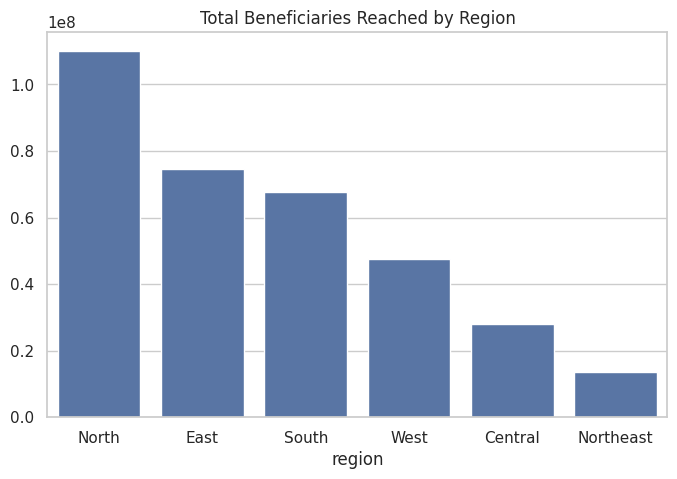

In [19]:
region_summary = df.groupby('region')['beneficiaries_reached'].sum().sort_values(ascending=False)
print("Beneficiaries Reached by Region:\n", region_summary)

plt.figure(figsize=(8,5))
sns.barplot(x=region_summary.index, y=region_summary.values)
plt.title("Total Beneficiaries Reached by Region")
plt.show()

STEP 10: Efficiency Metrics

Program Efficiency (Beneficiaries Reached / People Screened):
 program_name
National NCD Screening Programme                   0.876398
National Vector Borne Disease Control Programme    0.862106
Reproductive & Child Health Programme              0.856857
Swachh Bharat Sanitation Programme                 0.769233
Universal Immunization Programme                   0.762138
Revised National TB Control Programme              0.758289
Name: efficiency_ratio, dtype: float64


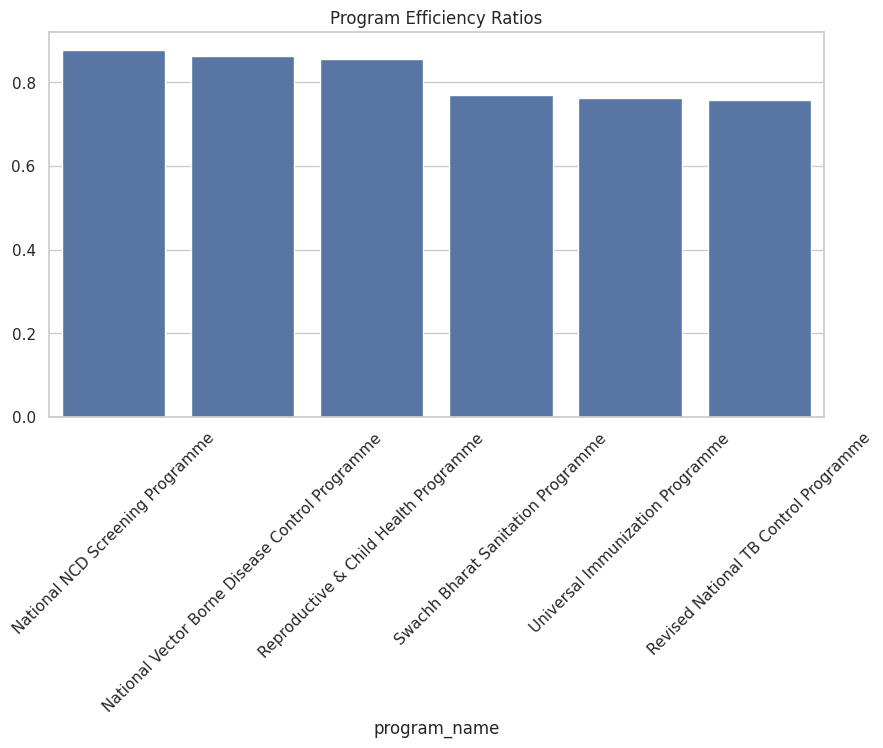

In [20]:
df['efficiency_ratio'] = df['beneficiaries_reached'] / df['people_screened']

efficiency_summary = df.groupby('program_name')['efficiency_ratio'].mean().sort_values(ascending=False)
print("Program Efficiency (Beneficiaries Reached / People Screened):\n", efficiency_summary)

plt.figure(figsize=(10,5))
sns.barplot(x=efficiency_summary.index, y=efficiency_summary.values)
plt.title("Program Efficiency Ratios")
plt.xticks(rotation=45)
plt.show()

STEP 11: Program Trends Over Time

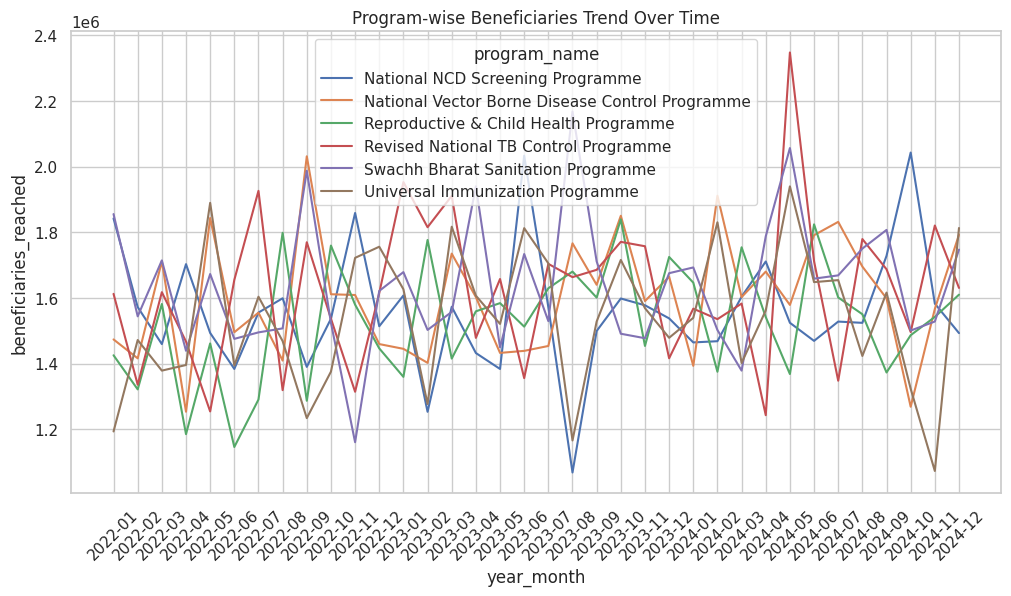

In [21]:
program_trends = df.groupby(['year_month','program_name'])['beneficiaries_reached'].sum().reset_index()

plt.figure(figsize=(12,6))
sns.lineplot(data=program_trends, x='year_month', y='beneficiaries_reached', hue='program_name')
plt.title("Program-wise Beneficiaries Trend Over Time")
plt.xticks(rotation=45)
plt.show()

STEP 12: Insights Summary

In [22]:
print("Top Programs by Beneficiaries Reached:")
print(df.groupby('program_name')['beneficiaries_reached'].sum().sort_values(ascending=False).head())

print("\nTop States by Beneficiaries Reached:")
print(df.groupby('state_name')['beneficiaries_reached'].sum().sort_values(ascending=False).head())

print("\nTop States by Maternal Health Beneficiaries:")
print(df.groupby('state_name')['maternal_health_beneficiaries'].sum().sort_values(ascending=False).head())

print("\nTop States by Child Immunization Count:")
print(df.groupby('state_name')['child_immunization_count'].sum().sort_values(ascending=False).head())

Top Programs by Beneficiaries Reached:
program_name
Swachh Bharat Sanitation Programme                 58985511
Revised National TB Control Programme              58335913
National Vector Borne Disease Control Programme    57596906
National NCD Screening Programme                   56178366
Universal Immunization Programme                   55526056
Name: beneficiaries_reached, dtype: int64

Top States by Beneficiaries Reached:
state_name
Uttar Pradesh     57197230
Maharashtra       29368089
Bihar             28953648
West Bengal       24331702
Madhya Pradesh    20798928
Name: beneficiaries_reached, dtype: int64

Top States by Maternal Health Beneficiaries:
state_name
Uttar Pradesh     13016888
Maharashtra        6529893
Bihar              6359662
West Bengal        5660782
Madhya Pradesh     5166644
Name: maternal_health_beneficiaries, dtype: int64

Top States by Child Immunization Count:
state_name
Uttar Pradesh     10330127777
Maharashtra        5607575647
Bihar              5571201

STEP 13: Save Results

In [23]:
df.to_csv("fact_health_programs_cleaned_final.csv", index=False)